**Task-1**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", X_test.shape)
print("Testing labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1789s 10us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images : (10000, 32, 32, 3)
Testing labels : (10000, 1)


In [2]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

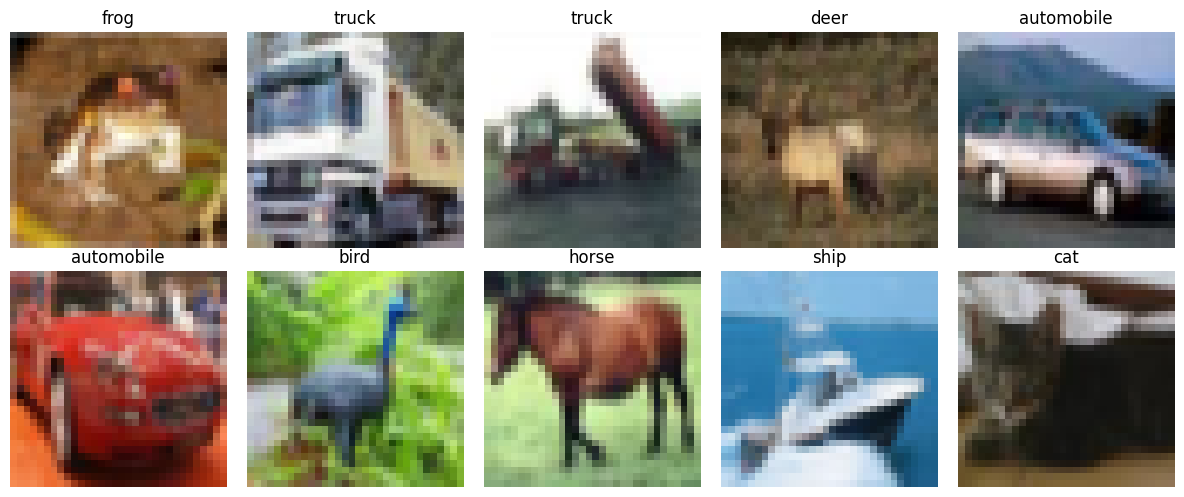

In [4]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Task-2**

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [6]:
IMG_SIZE = 96
NUM_CLASSES = 10
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_image(image, label):
    # Convert normalized [0,1] image back to [0,255]
    image = image * 255.0

    # Resize CIFAR-10 image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # MobileNetV2 preprocessing
    image = preprocess_input(image)

    return image, label

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = (
    train_ds
    .shuffle(10000)
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Data pipelines created successfully.")

Data pipelines created successfully.


In [8]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("MobileNetV2 loaded successfully.")
print("Number of layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Number of layers: 154


In [9]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)

print("Trainable layers:", trainable_layers)

Base model trainable: False
Trainable layers: 0


In [10]:
inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = base_model(
    inputs,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
print("Total parameters:", model.count_params())

print(
    "Trainable parameters:",
    np.sum([
        np.prod(v.shape)
        for v in model.trainable_variables
    ])
)

print(
    "Non-trainable parameters:",
    np.sum([
        np.prod(v.shape)
        for v in model.non_trainable_variables
    ])
)

Total parameters: 2423242
Trainable parameters: 165258
Non-trainable parameters: 2257984


**Task-3**

In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
import time

start_time = time.time()

history = model.fit(train_ds,validation_data=test_ds,epochs=10)

training_time = time.time() - start_time

print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.8290 - loss: 0.4996 - val_accuracy: 0.8568 - val_loss: 0.4064
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8742 - loss: 0.3635 - val_accuracy: 0.8618 - val_loss: 0.3954
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8896 - loss: 0.3124 - val_accuracy: 0.8634 - val_loss: 0.4124
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9073 - loss: 0.2673 - val_accuracy: 0.8637 - val_loss: 0.4149
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9191 - loss: 0.2290 - val_accuracy: 0.8612 - val_loss: 0.4386
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9324 - loss: 0.1912 - val_accuracy: 0.8622 - val_loss: 0.4510
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9433 - loss: 0.1583 - val_accuracy: 0.8626 - val_loss: 0.4719
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9540 -

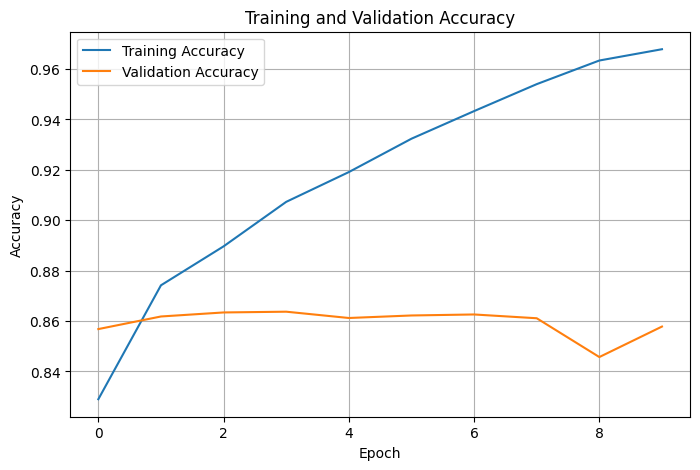

In [14]:
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "plots/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

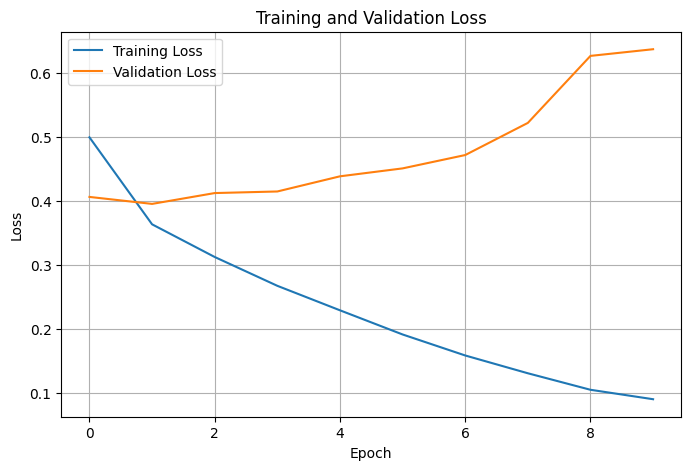

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "plots/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8578 - loss: 0.6374
Test Loss: 0.6374
Test Accuracy: 0.8578
Test Accuracy: 85.78%


In [17]:
print("========== TRANSFER LEARNING RESULTS ==========")

print(f"Final Training Accuracy : {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy           : {test_accuracy * 100:.2f}%")

print(f"Final Training Loss     : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss   : {history.history['val_loss'][-1]:.4f}")
print(f"Test Loss               : {test_loss:.4f}")

print(f"Training Time           : {training_time:.2f} seconds")
print(f"Total Parameters        : {model.count_params():,}")

========== TRANSFER LEARNING RESULTS ==========
Final Training Accuracy : 96.79%
Final Validation Accuracy: 85.78%
Test Accuracy           : 85.78%
Final Training Loss     : 0.0899
Final Validation Loss   : 0.6374
Test Loss               : 0.6374
Training Time           : 243.89 seconds
Total Parameters        : 2,423,242


In [18]:
# Keep the earlier MobileNetV2 layers frozen
base_model.trainable = True

# Freeze all layers except the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

print("Total MobileNetV2 layers:", len(base_model.layers))

print(
    "Trainable MobileNetV2 layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 20


In [19]:
for i, layer in enumerate(base_model.layers[-20:]):
    print(i + len(base_model.layers) - 20,
          layer.name,
          layer.trainable)

134 block_15_expand True
135 block_15_expand_BN True
136 block_15_expand_relu True
137 block_15_depthwise True
138 block_15_depthwise_BN True
139 block_15_depthwise_relu True
140 block_15_project True
141 block_15_project_BN True
142 block_15_add True
143 block_16_expand True
144 block_16_expand_BN True
145 block_16_expand_relu True
146 block_16_depthwise True
147 block_16_depthwise_BN True
148 block_16_depthwise_relu True
149 block_16_project True
150 block_16_project_BN True
151 Conv_1 True
152 Conv_1_bn True
153 out_relu True


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [21]:
start_finetune = time.time()

fine_tune_history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

fine_tune_time = time.time() - start_finetune

print(f"\nFine-tuning Time: {fine_tune_time:.2f} seconds")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 27ms/step - accuracy: 0.8597 - loss: 0.5705 - val_accuracy: 0.8490 - val_loss: 0.5211
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9224 - loss: 0.2209 - val_accuracy: 0.8581 - val_loss: 0.5610
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9432 - loss: 0.1616 - val_accuracy: 0.8579 - val_loss: 0.6324
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9553 - loss: 0.1272 - val_accuracy: 0.8678 - val_loss: 0.5667
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9645 - loss: 0.1032 - val_accuracy: 0.8799 - val_loss: 0.5593

Fine-tuning Time: 186.98 seconds


In [22]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print(f"Fine-tuned Test Loss: {fine_test_loss:.4f}")
print(f"Fine-tuned Test Accuracy: {fine_test_accuracy:.4f}")
print(f"Fine-tuned Test Accuracy: {fine_test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8799 - loss: 0.5593
Fine-tuned Test Loss: 0.5593
Fine-tuned Test Accuracy: 0.8799
Fine-tuned Test Accuracy: 87.99%


In [23]:
initial_accuracy = test_accuracy
fine_tuned_accuracy = fine_test_accuracy

improvement = (
    fine_tuned_accuracy - initial_accuracy
) * 100

print("========== FINE-TUNING COMPARISON ==========")

print(f"Before Fine-Tuning : {initial_accuracy * 100:.2f}%")
print(f"After Fine-Tuning  : {fine_tuned_accuracy * 100:.2f}%")
print(f"Improvement        : {improvement:.2f} percentage points")

========== FINE-TUNING COMPARISON ==========
Before Fine-Tuning : 85.78%
After Fine-Tuning  : 87.99%
Improvement        : 2.21 percentage points


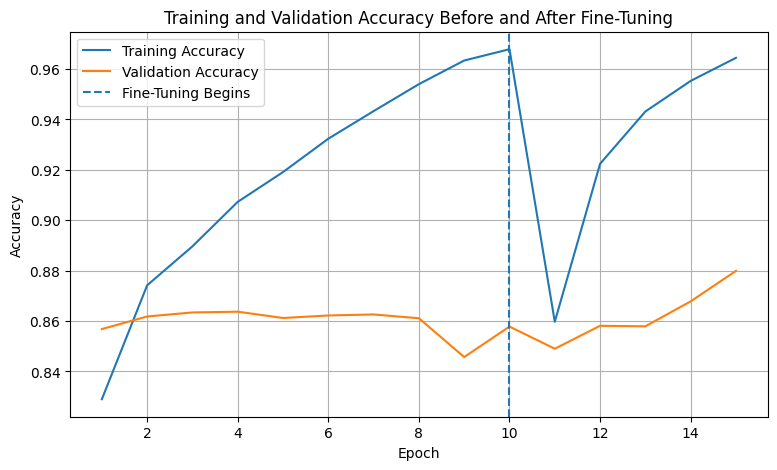

In [24]:
initial_train_acc = history.history["accuracy"]
initial_val_acc = history.history["val_accuracy"]

fine_train_acc = fine_tune_history.history["accuracy"]
fine_val_acc = fine_tune_history.history["val_accuracy"]

combined_train_acc = initial_train_acc + fine_train_acc
combined_val_acc = initial_val_acc + fine_val_acc

epochs = range(1, len(combined_train_acc) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    combined_train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    combined_val_acc,
    label="Validation Accuracy"
)

plt.axvline(
    x=len(initial_train_acc),
    linestyle="--",
    label="Fine-Tuning Begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Before and After Fine-Tuning")
plt.legend()
plt.grid(True)

plt.savefig(
    "plots/fine_tuning_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Generate predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = labels.numpy().flatten()

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))

Number of test samples: 10000


In [26]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.8874    0.9060    0.8966      1000
  automobile     0.9406    0.9340    0.9373      1000
        bird     0.8372    0.8740    0.8552      1000
         cat     0.8343    0.7300    0.7787      1000
        deer     0.8474    0.8610    0.8542      1000
         dog     0.8144    0.8470    0.8304      1000
        frog     0.8936    0.9150    0.9042      1000
       horse     0.9196    0.8690    0.8936      1000
        ship     0.9159    0.9370    0.9263      1000
       truck     0.9087    0.9260    0.9173      1000

    accuracy                         0.8799     10000
   macro avg     0.8799    0.8799    0.8794     10000
weighted avg     0.8799    0.8799    0.8794     10000



In [27]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[906   5  28   2  12   0   1   4  29  13]
 [ 13 934   1   1   0   0   2   0   8  41]
 [ 22   0 874  15  41  13  24   3   8   0]
 [ 14   3  32 730  40 111  37   9  11  13]
 [  5   0  32  15 861  22  23  37   2   3]
 [  3   0  15  78  14 847  11  22   8   2]
 [ 10   1  30  15  13  12 915   0   2   2]
 [  7   2  22  17  33  34   5 869   5   6]
 [ 25  10   8   1   1   1   3   1 937  13]
 [ 16  38   2   1   1   0   3   0  13 926]]


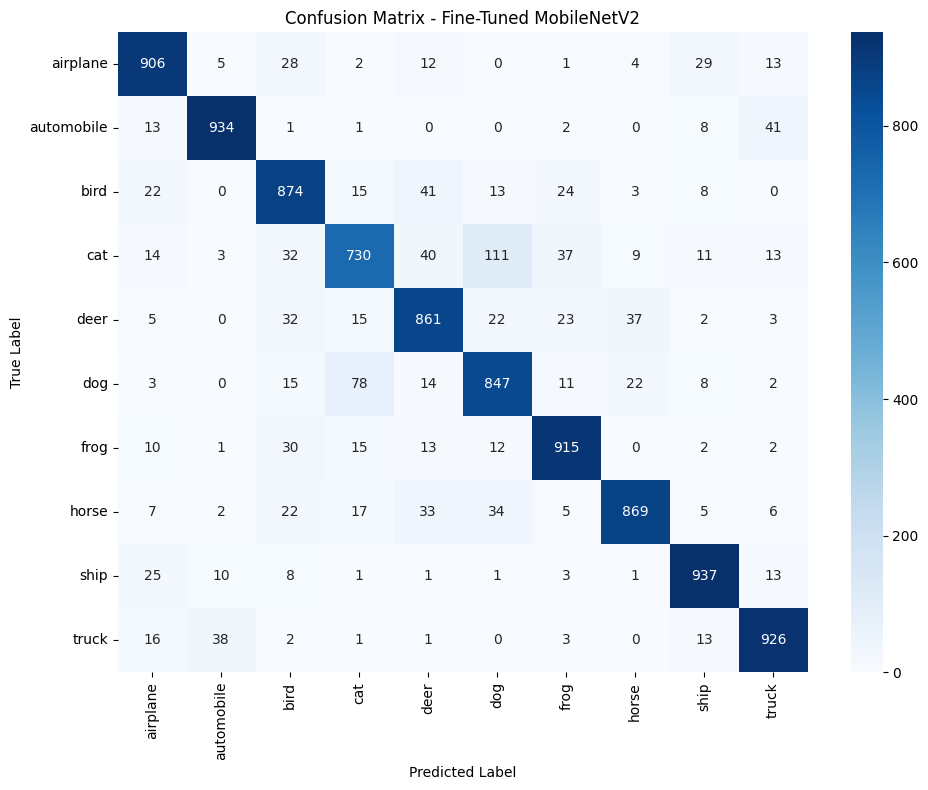

In [28]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned MobileNetV2")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
misclassified_indices = np.where(y_true != y_pred)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices)
)

Number of misclassified images: 1201


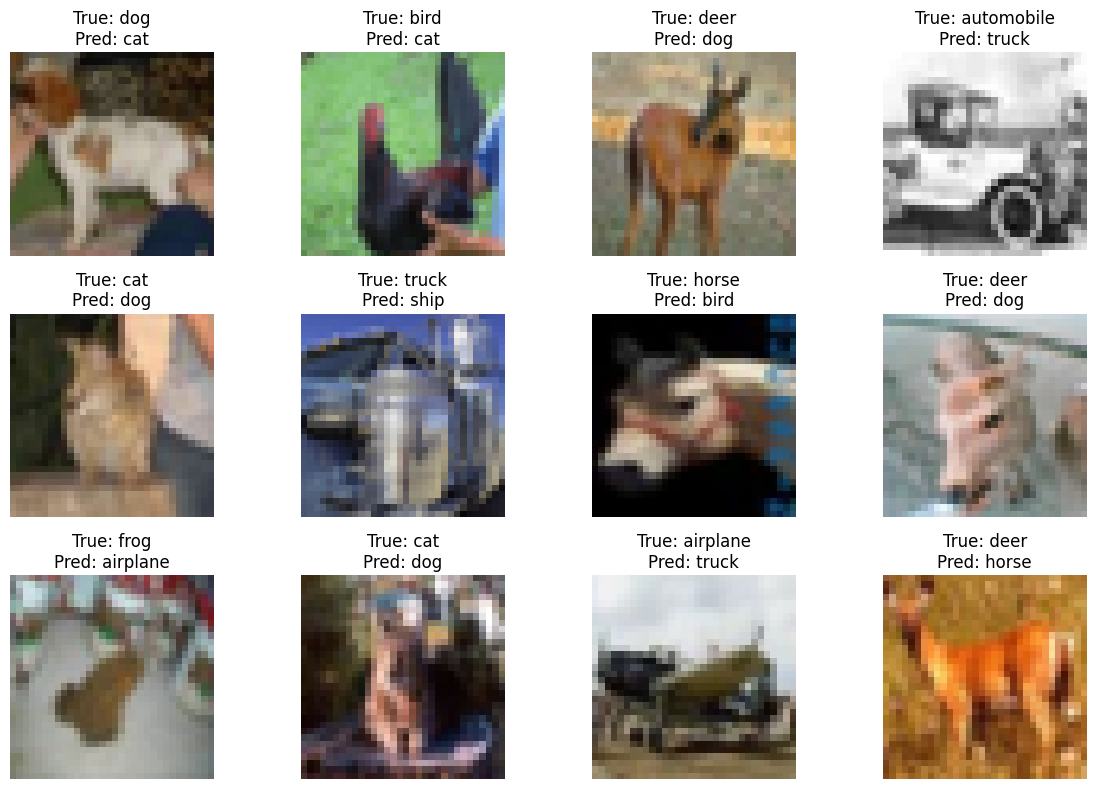

In [30]:
plt.figure(figsize=(12, 8))

num_images = min(12, len(misclassified_indices))

for i in range(num_images):
    idx = misclassified_indices[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx])

    true_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "plots/misclassified_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Generate predictions from the FINAL fine-tuned model
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = labels.numpy().flatten()

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))

Number of test samples: 10000


In [33]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("========== FINAL MODEL METRICS ==========")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")

========== FINAL MODEL METRICS ==========
Accuracy  : 87.99%
Precision : 87.99%
Recall    : 87.99%
F1-score  : 87.94%


In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.8874    0.9060    0.8966      1000
  automobile     0.9406    0.9340    0.9373      1000
        bird     0.8372    0.8740    0.8552      1000
         cat     0.8343    0.7300    0.7787      1000
        deer     0.8474    0.8610    0.8542      1000
         dog     0.8144    0.8470    0.8304      1000
        frog     0.8936    0.9150    0.9042      1000
       horse     0.9196    0.8690    0.8936      1000
        ship     0.9159    0.9370    0.9263      1000
       truck     0.9087    0.9260    0.9173      1000

    accuracy                         0.8799     10000
   macro avg     0.8799    0.8799    0.8794     10000
weighted avg     0.8799    0.8799    0.8794     10000



In [35]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[906   5  28   2  12   0   1   4  29  13]
 [ 13 934   1   1   0   0   2   0   8  41]
 [ 22   0 874  15  41  13  24   3   8   0]
 [ 14   3  32 730  40 111  37   9  11  13]
 [  5   0  32  15 861  22  23  37   2   3]
 [  3   0  15  78  14 847  11  22   8   2]
 [ 10   1  30  15  13  12 915   0   2   2]
 [  7   2  22  17  33  34   5 869   5   6]
 [ 25  10   8   1   1   1   3   1 937  13]
 [ 16  38   2   1   1   0   3   0  13 926]]


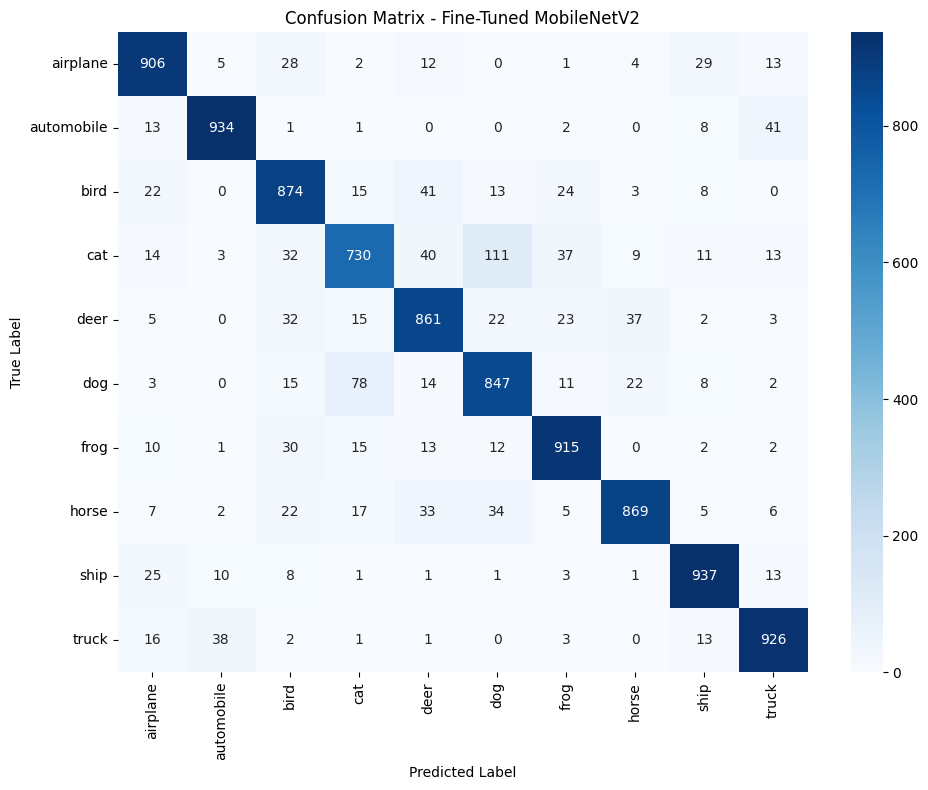

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned MobileNetV2")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
print("=" * 55)
print("          EX-4 FINAL RESULTS")
print("=" * 55)

print(f"Model                  : MobileNetV2")
print(f"Pretrained Weights     : ImageNet")
print(f"Input Size             : {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Batch Size             : {BATCH_SIZE}")
print(f"Initial Epochs         : 10")
print(f"Fine-Tuning Epochs     : 5")

print("\n--- Performance ---")

print(f"Before Fine-Tuning     : {test_accuracy * 100:.2f}%")
print(f"After Fine-Tuning      : {fine_test_accuracy * 100:.2f}%")
print(
    f"Improvement             : "
    f"{(fine_test_accuracy - test_accuracy) * 100:.2f} percentage points"
)

print(f"Precision              : {precision * 100:.2f}%")
print(f"Recall                 : {recall * 100:.2f}%")
print(f"F1-score               : {f1 * 100:.2f}%")

print("\n--- Model ---")

print(f"Total Parameters       : {model.count_params():,}")

print(f"\nInitial Training Time  : {training_time:.2f} seconds")
print(f"Fine-Tuning Time       : {fine_tune_time:.2f} seconds")
print(
    f"Total Training Time    : "
    f"{training_time + fine_tune_time:.2f} seconds"
)

print("=" * 55)

          EX-4 FINAL RESULTS
Model                  : MobileNetV2
Pretrained Weights     : ImageNet
Input Size             : 96x96x3
Batch Size             : 32
Initial Epochs         : 10
Fine-Tuning Epochs     : 5

--- Performance ---
Before Fine-Tuning     : 85.78%
After Fine-Tuning      : 87.99%
Improvement             : 2.21 percentage points
Precision              : 87.99%
Recall                 : 87.99%
F1-score               : 87.94%

--- Model ---
Total Parameters       : 2,423,242

Initial Training Time  : 243.89 seconds
Fine-Tuning Time       : 186.98 seconds
Total Training Time    : 430.87 seconds
